In [4]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [5]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [ ]:
benchmark = ffmpeg

In [6]:
generate_static_info(benchmark.binary)

In [7]:
static_info = get_static_info(benchmark.binary)
static_info

,id,name,size.bytecode,size.static
0,24,__wasm_call_ctors,8,864
1,25,undefined_weak:__wasilibc_find_relpath_alloc,4,504
2,26,_start,69,984
3,27,__SIG_IGN,3,512
4,28,__SIG_ERR,5,504
...,...,...,...,...
27485,27509,ff_tx_fft16_ns_int32_c,2188,3344
27486,27510,ff_tx_fft8_ns_int32_c,1144,2096
27487,27511,ff_tx_fft4_ns_int32_c,382,912
27488,27512,ff_tx_fft2_ns_int32_c,163,664


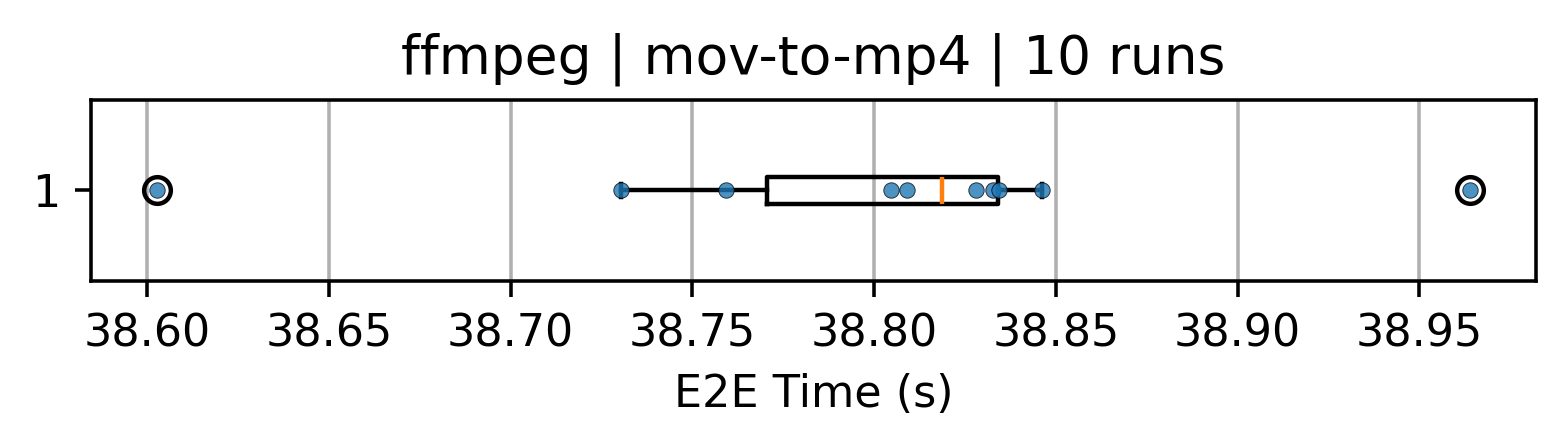

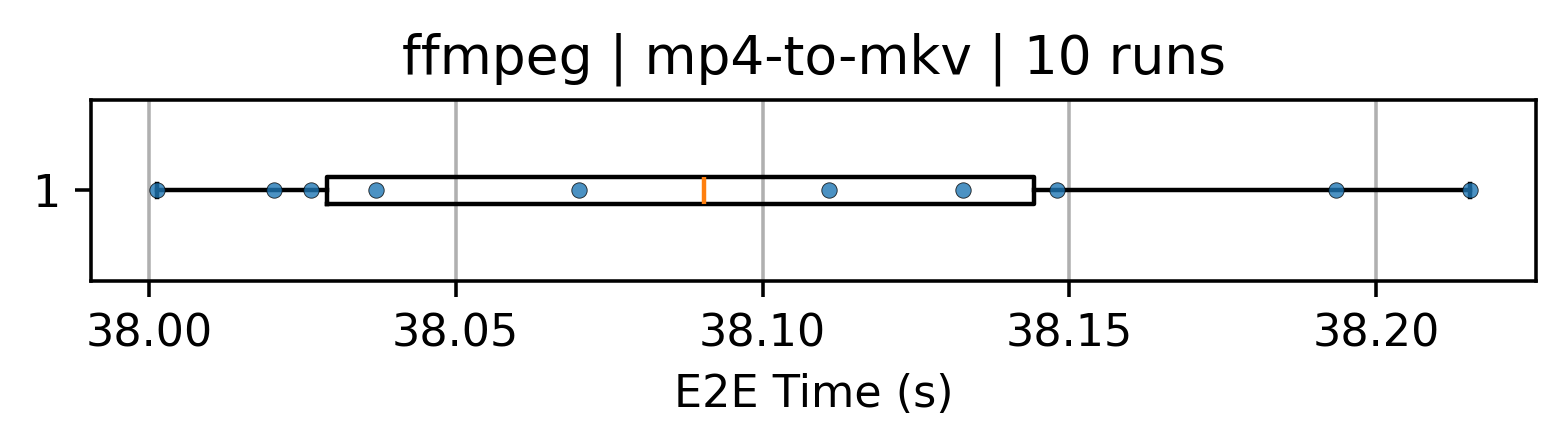

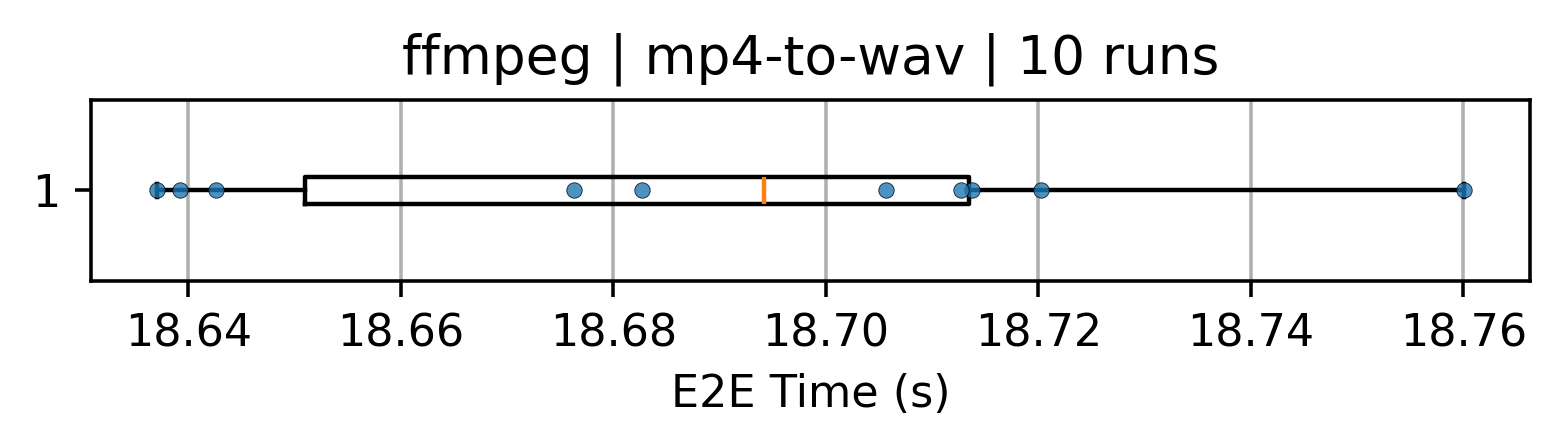

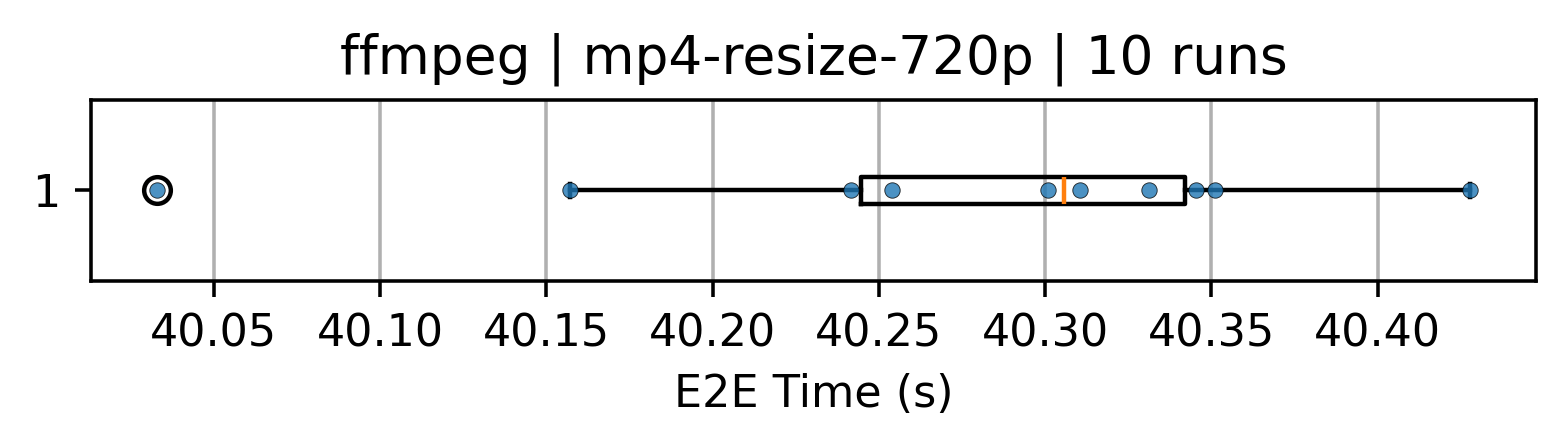

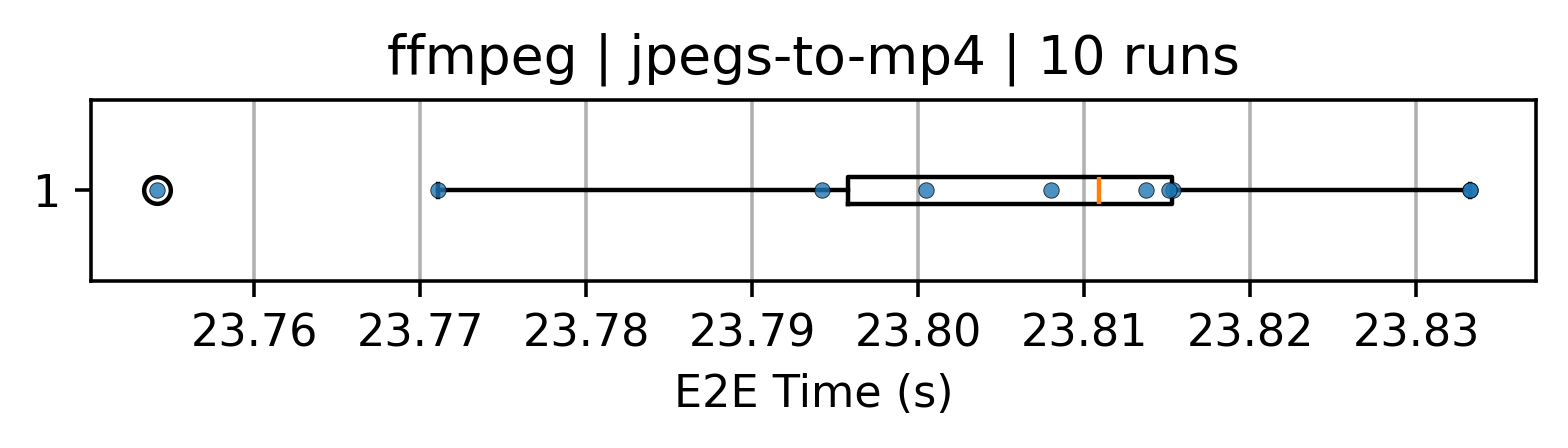

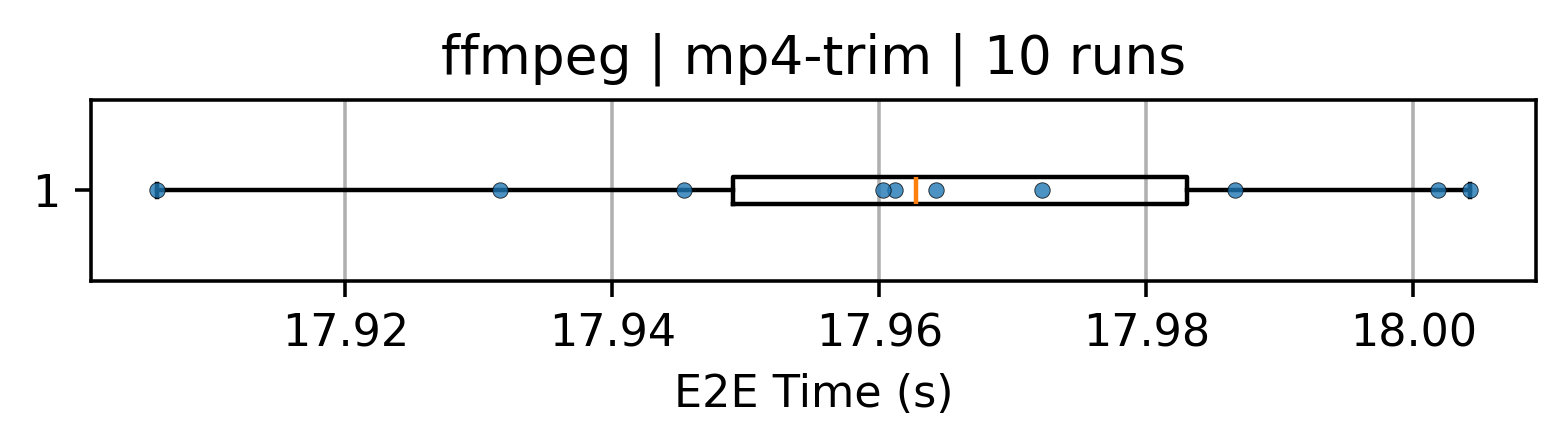

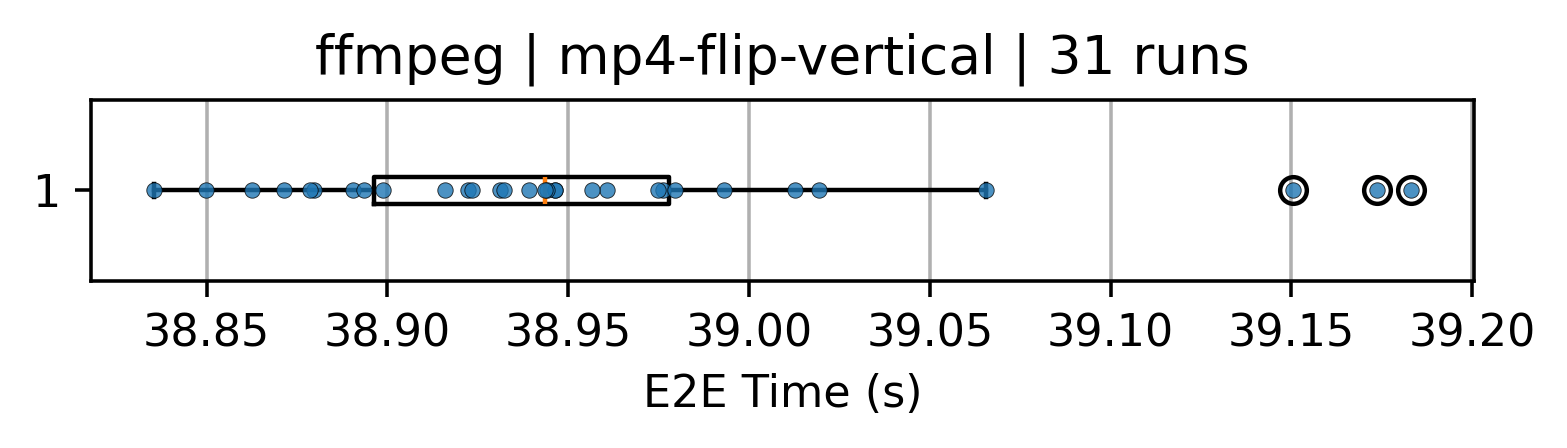

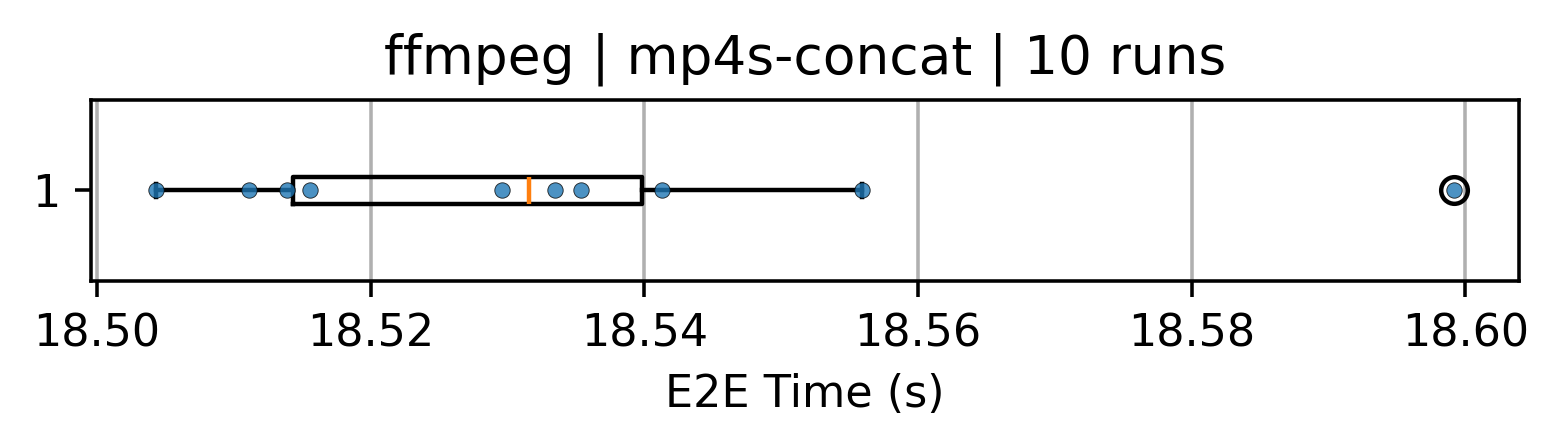

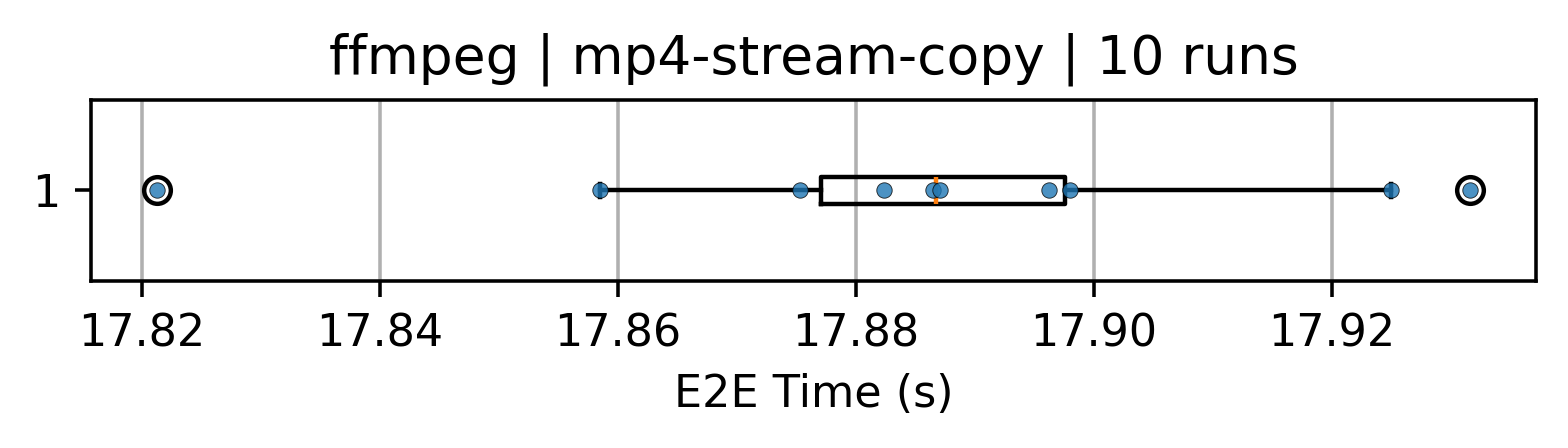

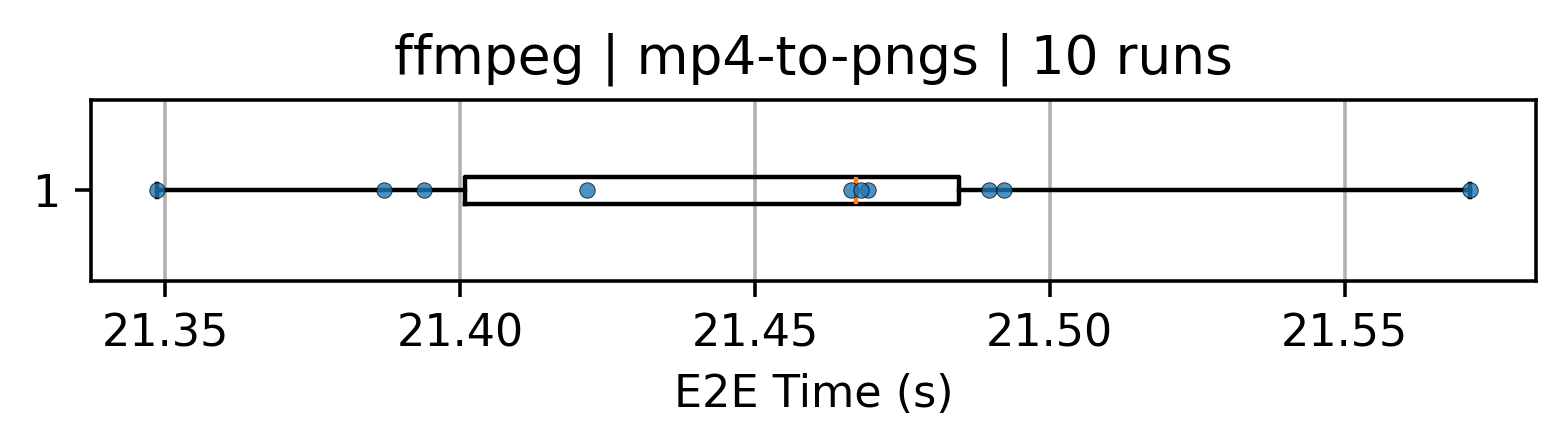

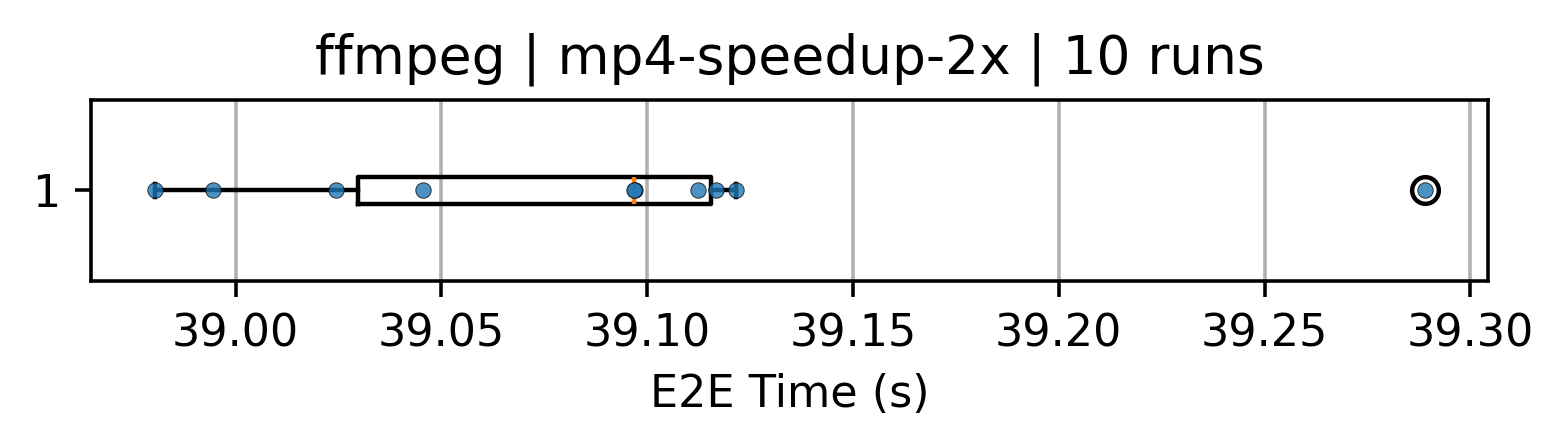

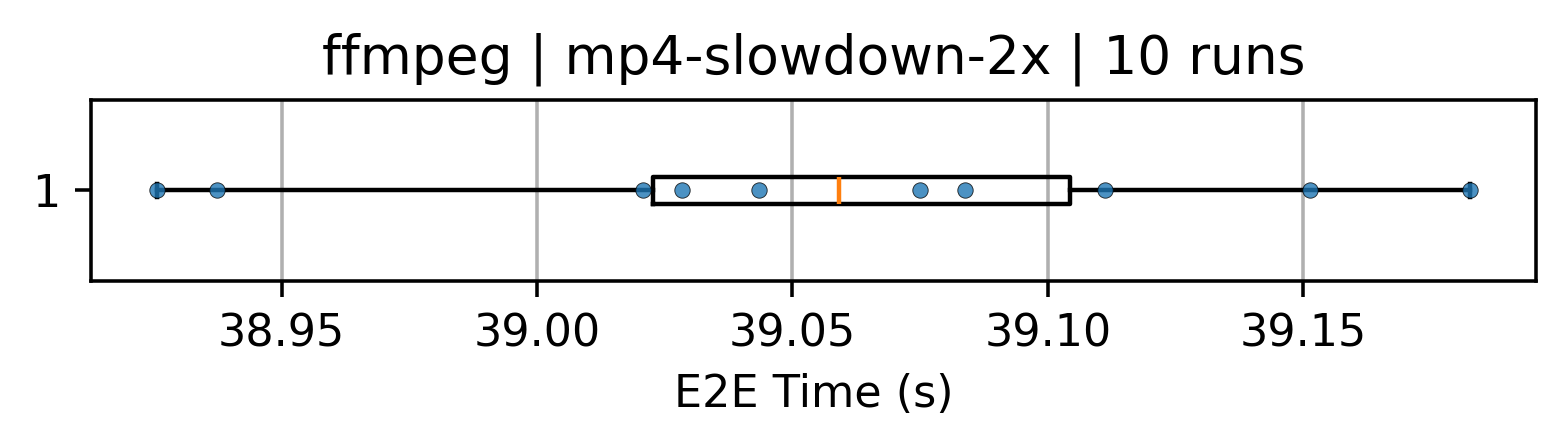

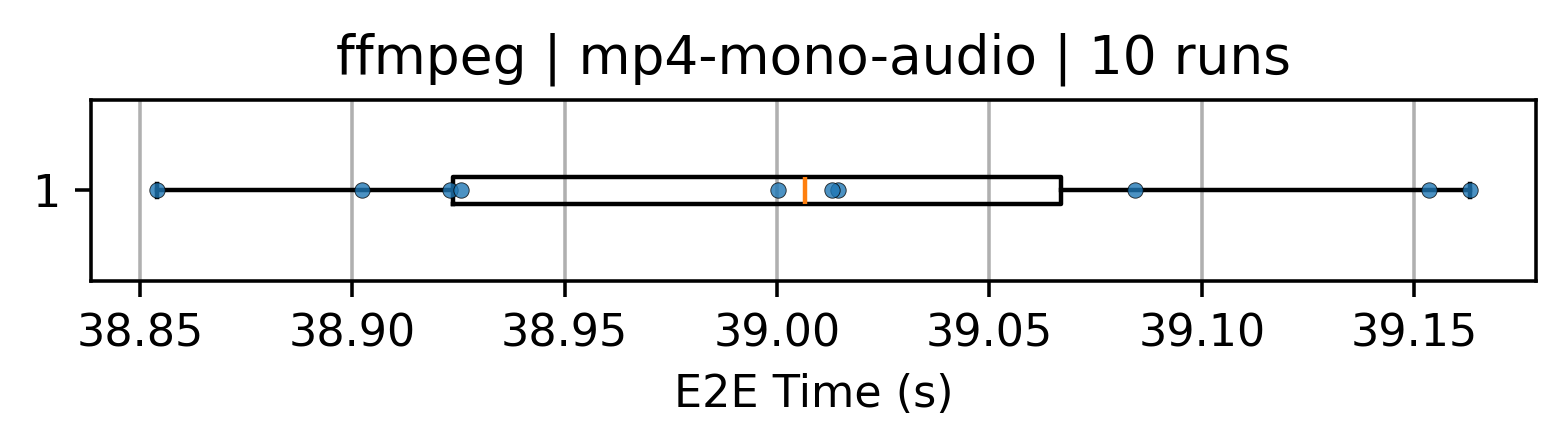

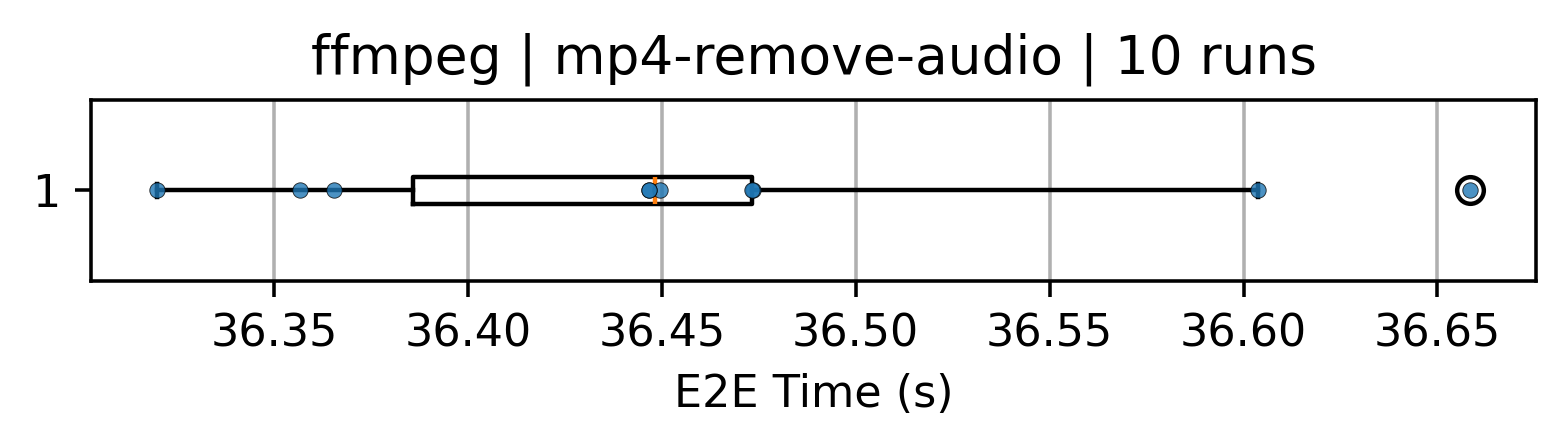

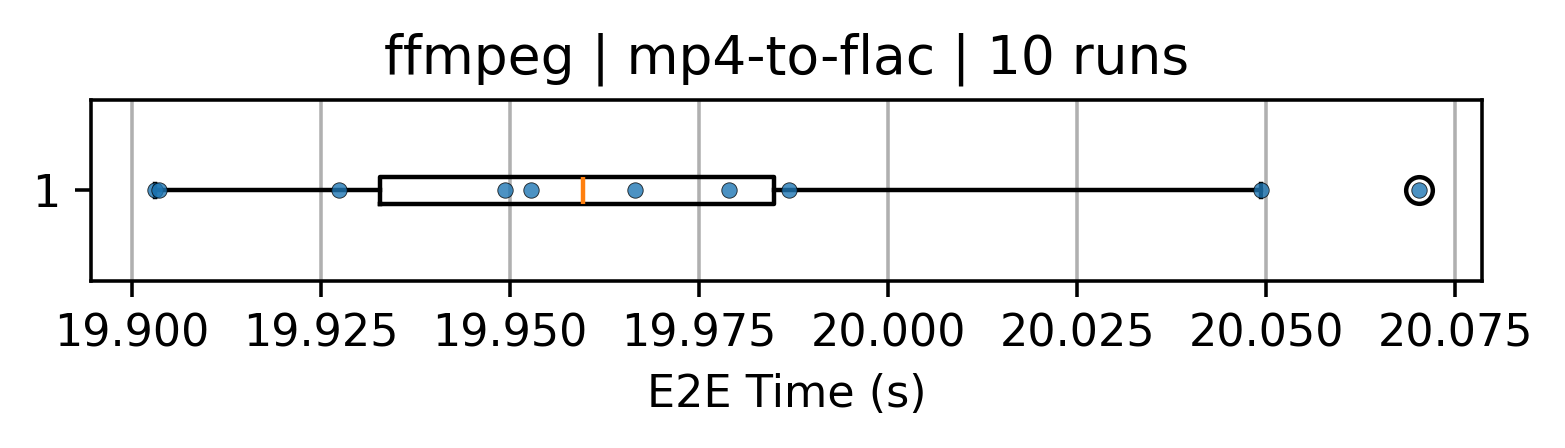

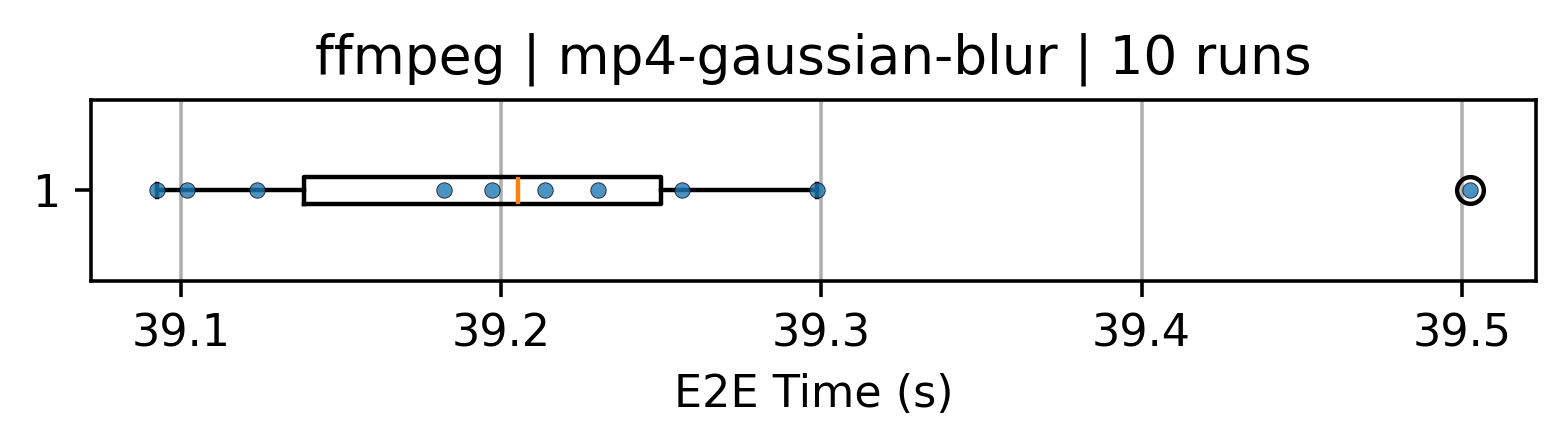

In [18]:
import matplotlib.pyplot as plt

for workload in benchmark.workloads:
    profile = Profile(profiles_root(benchmark.binary, workload.name, 'jit'))
    data = profile.e2e
    data = profile.waiting
    data = np.array(data, dtype=float) / 1e9

    plt.figure(figsize=(5, 1.5), dpi=320)
    plt.boxplot(data, vert=False)

    # overlay individual datapoints
    plt.scatter(data, np.zeros_like(data) + 1, s=12, alpha=0.8, color='tab:blue', edgecolors='black', linewidths=0.2, zorder=3)

    plt.xlabel('E2E Time (s)')
    plt.title(f'{benchmark.name} | {workload.name} | {len(data)} runs')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

In [6]:
generate_profile_oracle(benchmark)
generate_profile_union(benchmark)
generate_plans(benchmark)

[workload] default
[binary_size] 2412587
[workload] default
[plan] min_e2e.unconstrained.default_static
[profile] trained_on_default
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[profile] oracle
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[profile] union
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:static]==> {'static': 673, 'specialize': 13}
[plan] min_e2e.unconstrained.default_jit
[profile] trained_on_default
[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[plan] {'static': 132, 'specialize': 13} ==[default:jit]==> {'jit': 541, 'static': 132, 'specialize': 13}
[profile] oracle
[goal] EndToEndTime
Solving...
[status] Optima

In [8]:
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e.unconstrained.default_static') / 'oracle.json')
df = pd.merge(profile, plan, on='id', how='outer')
df

,id,name,size.bytecode,size.static,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,exec.spec,compilation.spec,size.dynamic.spec,mode
0,13,__wasm_call_ctors,6.0,808.0,4.728576e+06,0.0,1.0,1815102.0,808.0,6.491000e+04,0.000000e+00,1.0,0.0,1806322.0,808.0,static
1,14,_start,83.0,992.0,5.836000e+04,0.0,0.0,4669086.0,992.0,6.038000e+04,0.000000e+00,0.0,0.0,4496135.0,992.0,static
2,15,example1(),97.0,576.0,5.958880e+08,220000000.0,2621441.0,3582314.0,576.0,8.021589e+06,8.409000e+10,2621441.0,215000000.0,3556814.0,576.0,specialize
3,16,"example2a(int, int)",204.0,696.0,8.289911e+08,240000000.0,1048577.0,6080787.0,696.0,8.485667e+10,4.644000e+10,1048577.0,55000000.0,3576373.0,760.0,specialize
4,17,"example2b(int, int)",192.0,680.0,1.100748e+09,390000000.0,524289.0,5028767.0,680.0,1.317176e+11,8.185000e+10,524289.0,150000000.0,3506504.0,576.0,specialize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
682,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
683,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
684,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static


In [9]:
class PlanEvaluation:
    def __init__(self, static_info, base_profile, plan):
        e2e = 0
        exec = 0
        waiting = 0
        compilation = 0
        dynamic_code_size = 0
        static_code_size = 0

        # merge on both ('id', 'name')
        df = pd.merge(static_info, base_profile, on=['id', 'name', 'size.bytecode', 'size.static'], how='outer')

        df = pd.merge(df, plan, on='id', how='outer')
        df.drop('name', axis=1, inplace=True)
        df.fillna(0, inplace=True)
        # print(df.to_string())

        # iterate the rows of df
        for i, row in df.iterrows():
            mode = row['mode']
            if mode == 'interpret':
                e2e += row['exec.interp']
                exec += row['exec.interp']
                waiting += 0
                compilation += 0
                dynamic_code_size += 0
                static_code_size += 0
            elif mode == 'jit':
                e2e += row['exec.jit'] + row['compilation.jit']
                exec += row['exec.jit']
                waiting += row['compilation.jit']
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'static':
                e2e += row['exec.jit']  # like jit without compilation/waiting
                exec += row['exec.jit']  # like jit
                waiting += 0
                compilation += 0
                dynamic_code_size += row['size.dynamic.jit']  # also add the dynamic code
                static_code_size += row['size.static']
            elif mode == 'async':
                e2e += row['exec.jit'] + .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to e2e
                exec += row['exec.jit']
                waiting += .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to waiting
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'specialize':
                e2e += row['exec.spec'] + row['compilation.spec']
                exec += row['exec.spec']
                waiting += row['compilation.spec']
                compilation += row['compilation.spec']
                dynamic_code_size += row['size.dynamic.spec']
                static_code_size += 0
            else:
                raise ValueError(f'Unknown mode: {mode}')

        plan_modes = plan['mode'].value_counts().to_dict()
        self.jit = plan_modes.get('jit', 0)
        self.interpret = plan_modes.get('interpret', 0)
        self.async_compilation = plan_modes.get('async', 0)
        self.specialize = plan_modes.get('specialize', 0)
        self.static = plan_modes.get('static', 0)

        self.e2e = e2e
        self.exec = exec
        self.waiting = waiting
        self.compilation = compilation
        self.dynamic_code_size = dynamic_code_size
        self.static_code_size = static_code_size

    def __str__(self):
        return json.dumps({
            'jit': self.jit,
            'interpret': self.interpret,
            'async_compilation': self.async_compilation,
            'specialize': self.specialize,
            'static': self.static,
            'e2e': self.e2e,
            'exec': self.exec,
            'waiting': self.waiting,
            'compilation': self.compilation,
            'dynamic_code_size': self.dynamic_code_size,
            'static_code_size': self.static_code_size,
        }, indent=2)


PlanEvaluation(static_info, profile, plan)

In [10]:
class Planning:
    def __init__(self, goal, constraints, default):
        self.goal = goal
        self.constraints = constraints
        self.default = default

    def get_plan(self, static_info, base_profile):
        all_ids = static_info['id'].tolist()
        if self.goal is None:
            return pd.DataFrame({'id': all_ids, 'mode': [self.default] * len(all_ids)})
        solver = Solver(base_profile)
        solver.solve(self.goal, self.constraints, timeout=10)
        plan = solver.plan
        unplanned_ids = set(all_ids) - set(plan['id'].tolist())
        defaults = pd.DataFrame({'id': list(unplanned_ids), 'mode': [self.default] * len(unplanned_ids)})
        return pd.concat([plan, defaults])

In [11]:
plans = []
plans.append(('Interpreter', Planning(None, None, 'interpret')))
plans.append(('JIT', Planning(None, None, 'jit')))
plans.append(('AOT', Planning(None, None, 'static')))
plans.append(('Code = 0',
              Planning(EndToEndTime(),
                       [Constraint(StaticCodeSize(), upper_bound=0), Constraint(DynamicCodeSize(), upper_bound=0)],
                       'interpret')))
plans.append((r'Code $< 10\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=10_000),
                                        Constraint(DynamicCodeSize(), upper_bound=10_000)
                                        ], 'interpret')))

plans.append((r'Code $< 200\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=100_000),
                                        Constraint(DynamicCodeSize(), upper_bound=100_000)], 'interpret')))

# plans.append(('Code < 1MB (Default: interpret)',
#               Planning(EndToEndTime(), [Constraint(DynamicCodeSize(), upper_bound=1_000_000)], 'interpret')))
plans.append(('Unbounded Code',
              Planning(EndToEndTime(), [], 'static')))

evaluations = []
for plan_title, planning in plans:
    print(plan_title)
    plan = planning.get_plan(static_info, profile)
    evaluation = PlanEvaluation(static_info, profile, plan)
    print(evaluation)
    evaluations.append(evaluation)
    print("---------")

Interpreter
{
  "jit": 0,
  "interpret": 686,
  "async_compilation": 0,
  "specialize": 0,
  "static": 0,
  "e2e": 1224790000000.0,
  "exec": 1224790000000.0,
  "waiting": 0,
  "compilation": 0,
  "dynamic_code_size": 0,
  "static_code_size": 0
}
---------
JIT
{
  "jit": 686,
  "interpret": 0,
  "async_compilation": 0,
  "specialize": 0,
  "static": 0,
  "e2e": 6165572208.0,
  "exec": 4940000000.0,
  "waiting": 1225572208.0,
  "compilation": 1225572208.0,
  "dynamic_code_size": 208880.0,
  "static_code_size": 0
}
---------
AOT
{
  "jit": 0,
  "interpret": 0,
  "async_compilation": 0,
  "specialize": 0,
  "static": 686,
  "e2e": 4940000000.0,
  "exec": 4940000000.0,
  "waiting": 0,
  "compilation": 0,
  "dynamic_code_size": 208880.0,
  "static_code_size": 905976
}
---------
Code = 0
[goal] EndToEndTime
[constraint] StaticCodeSize <= 0
[constraint] DynamicCodeSize <= 0
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
{
  "jit": 0,
  "interpret": 686,
  "async_compilation": 0,
  "s

In [12]:
# Wong colorblind-friendly palette (prints well in grayscale)
INTERP_COLOR  = '#D55E00'  # Vermillion
JIT_COLOR     = '#56B4E9'  # Sky Blue
AOT_COLOR     = '#009E73'  # Bluish Green
CAPER_COLOR   = '#CC79A7'  # Reddish Purple

colors = [INTERP_COLOR, JIT_COLOR, AOT_COLOR]
for i in range(len(plans[3:])):
    colors.append(CAPER_COLOR)

In [13]:
code_sizes = [e.static_code_size + e.dynamic_code_size for e in evaluations]
e2es = [e.e2e for e in evaluations]
plans_titles = [plan_title for plan_title, _ in plans]

In [14]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

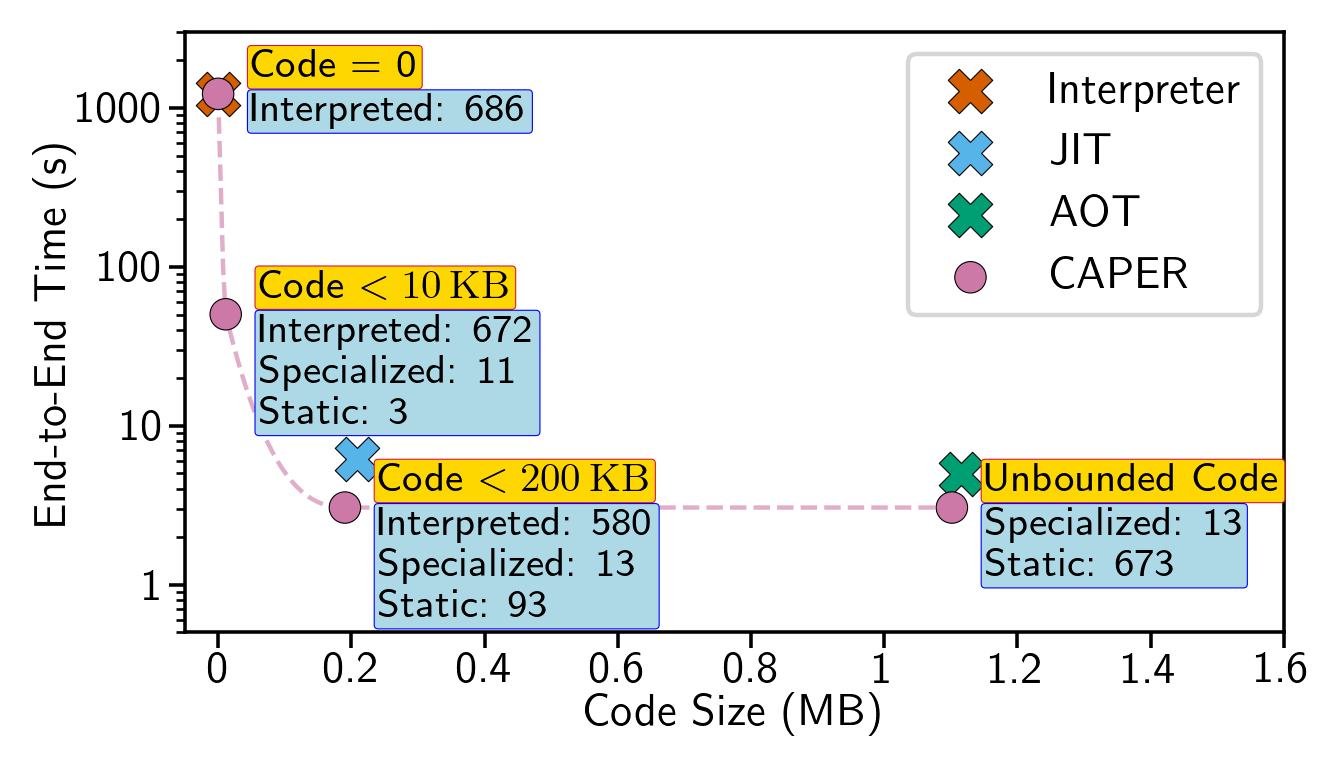

In [20]:
fig, ax = plt.subplots(figsize=(4, 2.2), dpi=320)

linewidth = 0.25
ax.scatter(code_sizes[0], e2es[0], color=colors[0], label=plans_titles[0], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[1], e2es[1], color=colors[1], label=plans_titles[1], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[2], e2es[2], color=colors[2], label=plans_titles[2], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)

ax.scatter(code_sizes[3:], e2es[3:], color=colors[3:], label='CAPER', alpha=1, edgecolor='black', linewidth=linewidth,
           marker='o', s=50)

from scipy.interpolate import PchipInterpolator
_caper_xs = np.array(code_sizes[3:], dtype=float)
_caper_ys = np.array(e2es[3:], dtype=float)
_sort_idx = np.argsort(_caper_xs)
_caper_xs = _caper_xs[_sort_idx]
_caper_ys = _caper_ys[_sort_idx]
_pchip = PchipInterpolator(_caper_xs, np.log10(_caper_ys))
_x_curve = np.linspace(_caper_xs[0], _caper_xs[-1], 300)
_y_curve = 10 ** _pchip(_x_curve)
ax.plot(_x_curve, _y_curve, color=CAPER_COLOR, linewidth=1.0, linestyle='--', alpha=0.6, zorder=0)

LEFT_PADDING = 50000
for i in range(len(plans[3:])):
    eval = evaluations[3 + i]
    text = plans_titles[3 + i]
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1.9, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='gold', edgecolor='crimson', linewidth=linewidth, boxstyle='round,pad=0.1'))
    text = ''
    if eval.interpret:
        text += f'Interpreted: {eval.interpret}\n'
    if eval.jit:
        text += f'JIT: {eval.jit}\n'
    if eval.specialize:
        text += f'Specialized: {eval.specialize}\n'
    if eval.async_compilation:
        text += f'Async: {eval.async_compilation}\n'
    if eval.static:
        text += f'Static: {eval.static}\n'
    text = text.strip()
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='lightblue', edgecolor='blue', linewidth=linewidth, boxstyle='round,pad=0.1'))

# make y log
ax.set_ylim(5e8, 3e12)
ax.set_yscale('log')
ax.set_yticks([1e9, 1e10, 1e11, 1e12])
ax.set_yticklabels(['1', '10', '100', '1000'])

# set x lim to 1.5MB
ax.set_xlim(-50000, 1600000)
# 0, 200k, 400k, 600k, ..., 1MB
ax.set_xticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000, 1600000])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1', '1.2', '1.4', '1.6'])

ax.tick_params(axis='both', pad=1)

ax.set_xlabel('Code Size (MB)', labelpad=0)
ax.set_ylabel('End-to-End Time (s)', labelpad=0)
# ax.set_title(f'{benchmark.name} Compilation Plans Comparison')
ax.legend()

# make it tight
plt.tight_layout(pad=0)

# to pdf
plt.savefig(f'out/motivation.pdf', bbox_inches='tight', dpi=320, format='pdf', transparent=True, pad_inches=0)

plt.show()

In [16]:
plans_fns = []
for plan_title, planning in plans[3:][::-1]:
    # print(plan_title)
    plan = planning.get_plan(static_info, profile)
    plans_fns.append((plan_title, plan['mode'].tolist()))

[goal] EndToEndTime
Solving...
[status] Optimal
[elapsed time] 0.02 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 100000
[constraint] DynamicCodeSize <= 100000
Solving...
[status] Optimal
[elapsed time] 0.08 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 10000
[constraint] DynamicCodeSize <= 10000
Solving...


[status] Optimal
[elapsed time] 0.07 seconds
[goal] EndToEndTime
[constraint] StaticCodeSize <= 0
[constraint] DynamicCodeSize <= 0
Solving...
[status] Optimal
[elapsed time] 0.01 seconds


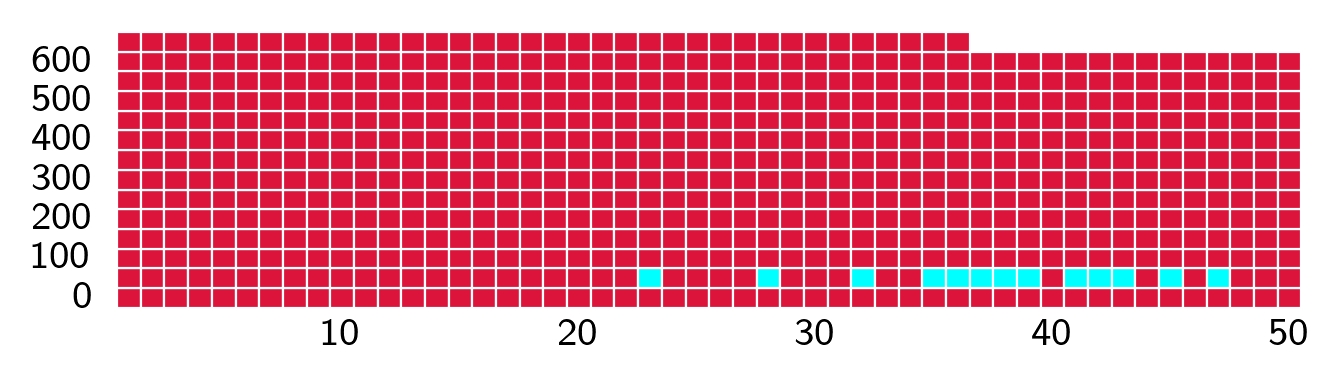

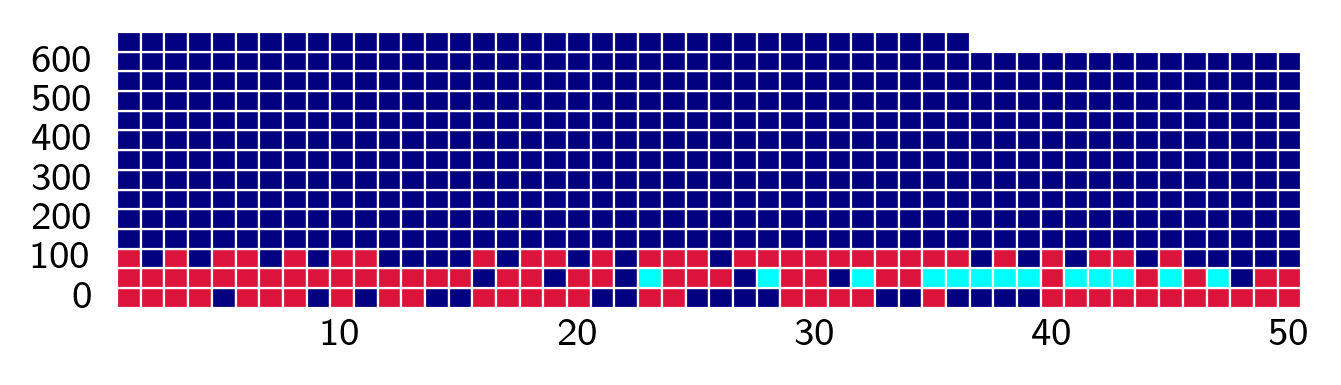

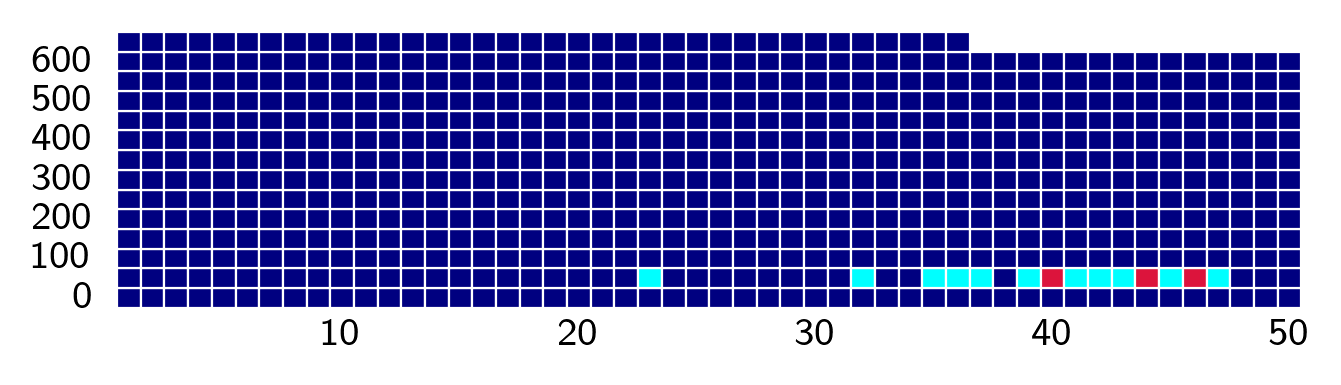

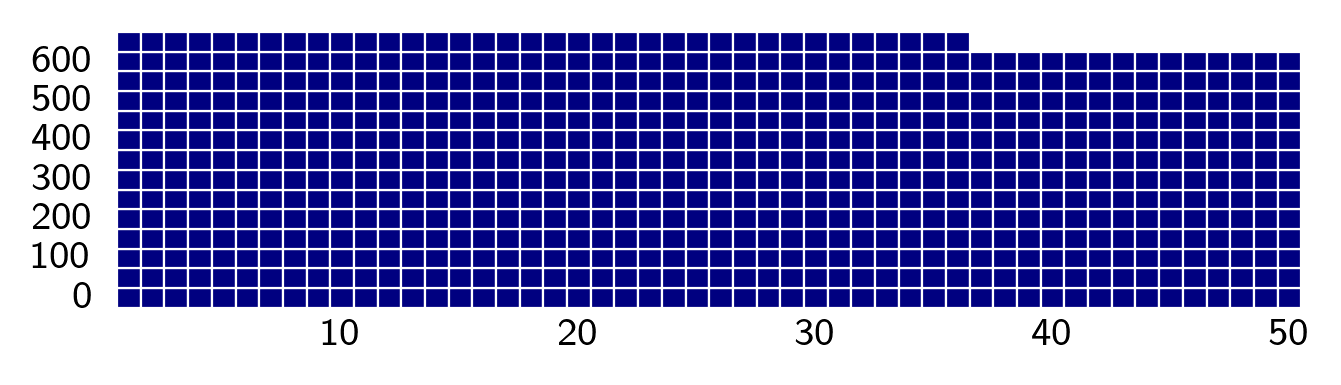

In [18]:
import matplotlib.pyplot as plt



def get_fn_color(mode):
    if mode == 'interpret':
        return 'navy'
    elif mode == 'jit':
        return JIT_COLOR
    elif mode == 'static':
        return 'crimson'
    elif mode == 'async':
        return '#FF00FF'
    elif mode == 'specialize':
        return '#00FFFF'
    else:
        return CAPER_COLOR

columns = 50

width = 1
height = 1


# fig, axs = plt.subplots(len(plans_fns), 1, figsize=(4, len(plans_fns) * .5), dpi=320, sharex=True)

cnt = 0
for plan_title, fns in plans_fns:
    fig, ax = plt.subplots(figsize=(4, 1), dpi=320, sharex=True)

    for i, fn_mode in enumerate(fns):
        x = (i%columns) * (width)
        y = i // columns * (height)
        ax.add_patch(plt.Rectangle((x, y), width, height, linewidth=.5, edgecolor='white', facecolor=get_fn_color(fn_mode)))

    # write the 0, 100, 200, ... labels on the left of the plot
    for i in range(0, len(fns), 100):
        ax.text(-width, (i // columns) * height + height/2, str(i), fontsize=9, ha='right', va='center')


    ax.set_xlim(-width, columns * width)
    ax.set_ylim(0, ((len(fns) - 1) // columns + 1) * height)

    # ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # write the plan title on the top middle of the plot
    # ax.set_title(plan_title, fontsize=4, pad=1)

    # write 20, 40, 60, 80 labels on the top of the plot
    for i in range(10, columns+1, 10):
        ax.text((i-1) * width + width/2, -height+height/2, str(i), fontsize=9, ha='center', va='top')


    # tight layout
    plt.tight_layout(pad=0)

    # to pdf
    plt.savefig(f'out/plans.{cnt}.pdf', bbox_inches='tight', dpi=320, format='pdf', pad_inches=0, transparent=True)

    plt.show()
    cnt += 1